In [152]:
import torch
import matplotlib.pyplot as plt

In [153]:
names = []
with open('names.txt') as w:
    names += w.read().splitlines()
names[:3]

['emma', 'olivia', 'ava']

In [154]:
EOF='.'

In [155]:
for word in names[:1]:
    data = [EOF]+list(word)+[EOF]
    for x,y in zip(data, data[1:]):
        print(x, y)

. e
e m
m m
m a
a .


In [156]:
padding=1
x_counts = torch.zeros((27,27), dtype=torch.int)+padding

In [157]:
# def ctoi(s:str)->int:
#     return 26 if s==EOF else ord(s) - ord('a')
    
# def itoc(i:int)->str:
#     return EOF if i==26 else chr(i + ord('a'))
    
# assert ctoi(EOF) == 26
# assert ctoi('a') == 0
# assert ctoi('e') == 4
# assert itoc(4) == 'e'

In [158]:
chars = sorted(list(set(''.join(names))))
ctoi = {s: i + 1 for i, s in enumerate(chars)}
ctoi['.'] = 0

itoc = {i: s for s, i in ctoi.items()}

In [159]:
for word in names:
    data = [EOF]+list(word)+[EOF]
    
    for x,y in zip(data, data[1:]):
        xi, yi = ctoi[x], ctoi[y]
        x_counts[xi,yi] +=1

In [160]:
x_counts.dtype

torch.int32

(-0.5, 26.5, 26.5, -0.5)

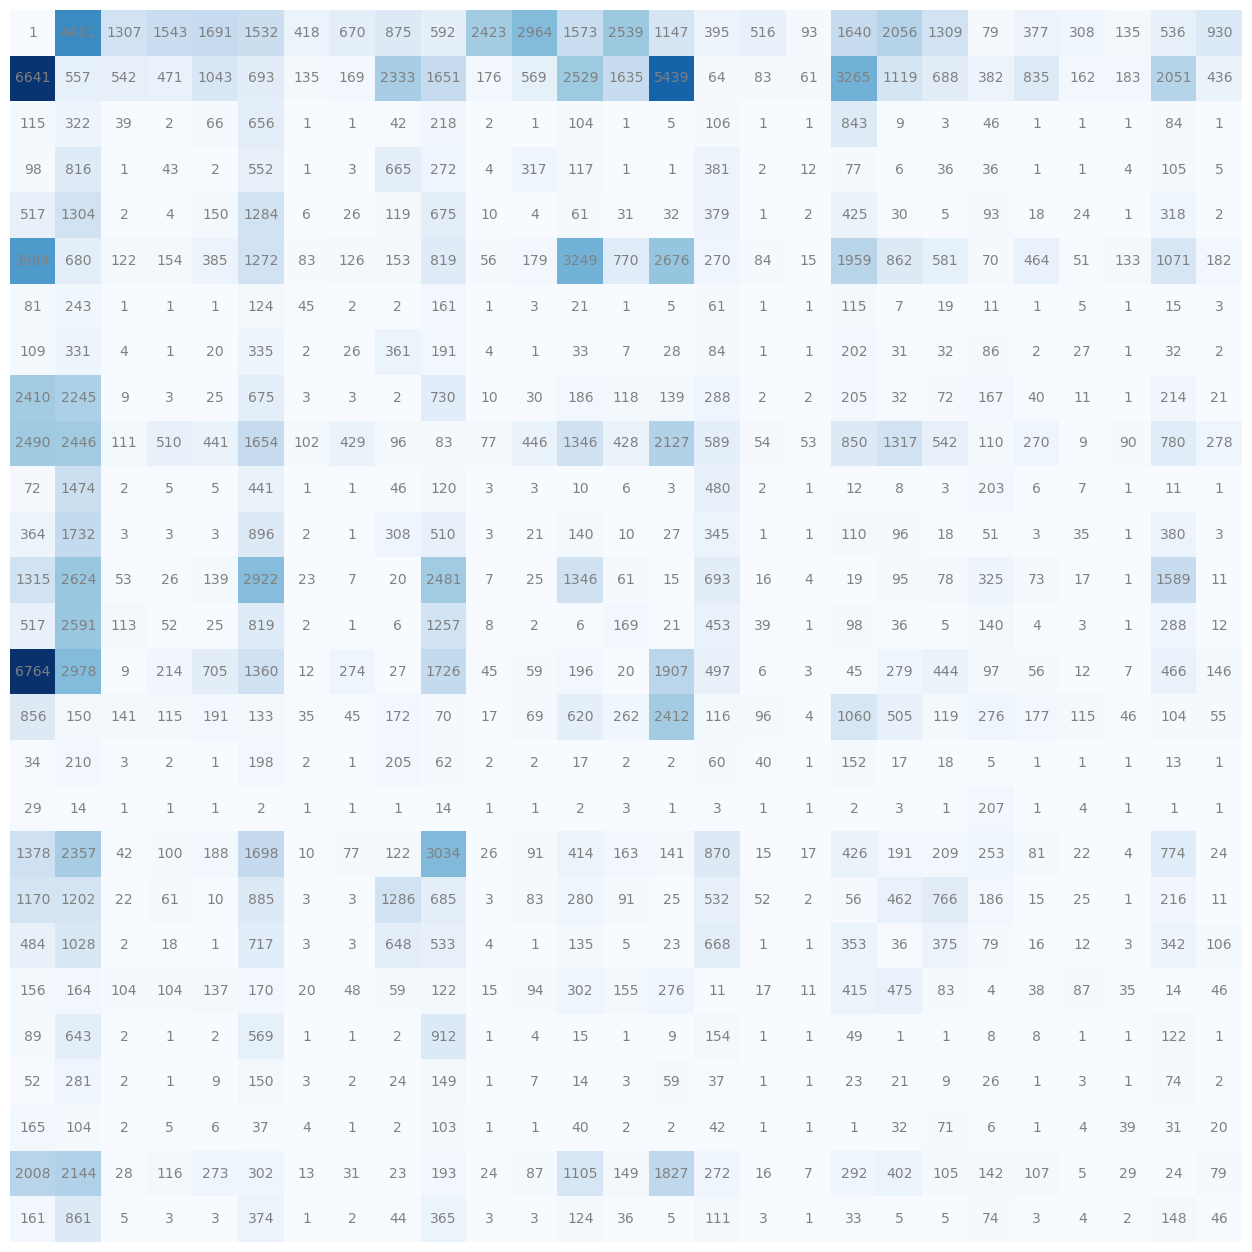

In [161]:
plt.figure(figsize=(16,16))
plt.imshow(x_counts, cmap='Blues')
for i in range(27):
    for j in range(27):
        # chstr = itoc[i] + itoc[j]
        plt.text(j, i, x_counts[i, j].item(), ha="center", va="center", color='gray')

plt.axis('off')

In [162]:
P = x_counts / x_counts.sum(1, keepdim=True)
P[0,-1], P.shape # a as last word prob

(tensor(0.0290), torch.Size([27, 27]))

In [163]:
P[0]

tensor([3.1192e-05, 1.3759e-01, 4.0767e-02, 4.8129e-02, 5.2745e-02, 4.7785e-02,
        1.3038e-02, 2.0898e-02, 2.7293e-02, 1.8465e-02, 7.5577e-02, 9.2452e-02,
        4.9064e-02, 7.9195e-02, 3.5777e-02, 1.2321e-02, 1.6095e-02, 2.9008e-03,
        5.1154e-02, 6.4130e-02, 4.0830e-02, 2.4641e-03, 1.1759e-02, 9.6070e-03,
        4.2109e-03, 1.6719e-02, 2.9008e-02])

In [164]:
seed=2147483647

In [165]:
# p = torch.ones(27).float()
# p /= p.sum()
# p[:3]

In [166]:
p = x_counts[0].float()
p /= p.sum()

g = torch.Generator().manual_seed(2147483647)

ix = torch.multinomial(p,num_samples=1,replacement=True,generator=g).item()

ix, itoc[ix]

(10, 'j')

In [167]:
g = torch.Generator().manual_seed(seed)

for i in range(5):
  out = []
  ix = 0
  while True:
    p = P[ix]
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itoc[ix])
    if ix == 0:
      break
  print(''.join(out))

junide.
janasah.
p.
cony.
a.


In [168]:
log_likelihood=0.0
n=0

for word in names:
    data = [EOF]+list(word)+[EOF]
    for x,y in zip(data, data[1:]):
        xi =ctoi[x]
        yi =ctoi[y]
        prob = P[xi,yi]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n+=1
        # print(f'{x}{y} : {prob:.4f} {logprob:.4f}')

print(f'{log_likelihood:.4f}')
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n=}')

-559951.5625
nll=tensor(559951.5625)
nll/n=tensor(2.4544)


In [169]:
P[0,:].sum()

tensor(1.)

In [170]:
xs, ys = [],[]

for w in names[:1]:
    chs = [EOF]+list(w)+[EOF]
    for c1, c2 in zip(chs, chs[1:]):
        i1, i2 = ctoi[c1], ctoi[c2]
        xs.append(i1)
        ys.append(i2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

In [171]:
import torch.nn.functional as F

In [172]:
x_enc = F.one_hot(xs, num_classes=27).float()
x_enc.shape, xs.shape

(torch.Size([5, 27]), torch.Size([5]))

In [173]:
W = torch.randn(27, 27, generator=g, requires_grad=True)
x_enc.shape, W.shape

(torch.Size([5, 27]), torch.Size([27, 27]))

In [174]:
(x_enc@W)[3, 13]

tensor(0.9322, grad_fn=<SelectBackward0>)

In [175]:
x_enc[3]

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [176]:
W[:,13]

tensor([-0.8815, -0.5132, -0.3639, -1.2320, -0.2000, -0.2109,  0.4113, -0.6130,
        -0.5254,  1.3843, -1.6860,  1.0715, -1.8674,  0.9322, -0.4441, -0.5684,
        -0.9885, -0.6144,  1.8654,  2.5270,  1.2820,  0.2986,  0.7539, -1.7581,
         1.3865, -1.3519,  0.7101], grad_fn=<SelectBackward0>)

In [177]:
(x_enc[3] * W[:, 13]).sum()

tensor(0.9322, grad_fn=<SumBackward0>)

In [178]:
logits = x_enc @ W # log counts
counts = logits.exp()
prob = counts/counts.sum(1, keepdims=True)
prob

tensor([[0.0025, 0.0104, 0.0172, 0.0109, 0.1280, 0.0237, 0.0078, 0.0133, 0.2163,
         0.0142, 0.0424, 0.0720, 0.0087, 0.0094, 0.0099, 0.0177, 0.1043, 0.0549,
         0.0111, 0.0079, 0.0527, 0.0139, 0.0089, 0.0261, 0.0472, 0.0018, 0.0667],
        [0.0849, 0.0066, 0.0191, 0.0146, 0.0466, 0.0184, 0.0324, 0.1156, 0.0838,
         0.0085, 0.1664, 0.0272, 0.0150, 0.0158, 0.0092, 0.0021, 0.0096, 0.0465,
         0.0211, 0.0123, 0.0358, 0.0151, 0.0103, 0.0094, 0.1440, 0.0061, 0.0237],
        [0.0245, 0.0170, 0.0217, 0.0324, 0.0273, 0.0248, 0.0108, 0.0138, 0.0053,
         0.0657, 0.2264, 0.0109, 0.1082, 0.0693, 0.0393, 0.0492, 0.0091, 0.0091,
         0.0055, 0.0124, 0.0232, 0.0804, 0.0199, 0.0144, 0.0286, 0.0400, 0.0108],
        [0.0245, 0.0170, 0.0217, 0.0324, 0.0273, 0.0248, 0.0108, 0.0138, 0.0053,
         0.0657, 0.2264, 0.0109, 0.1082, 0.0693, 0.0393, 0.0492, 0.0091, 0.0091,
         0.0055, 0.0124, 0.0232, 0.0804, 0.0199, 0.0144, 0.0286, 0.0400, 0.0108],
        [0.0356, 0.0828,

In [179]:
prob[0].sum()

tensor(1.0000, grad_fn=<SumBackward0>)

In [180]:
for i in range(counts.shape[0]):
    s = 0
    row_sum = counts[i, :].sum()
    for j in range(counts.shape[1]):
        s += counts[i, j] / row_sum
    print(s)

tensor(1., grad_fn=<AddBackward0>)
tensor(1., grad_fn=<AddBackward0>)
tensor(1.0000, grad_fn=<AddBackward0>)
tensor(1.0000, grad_fn=<AddBackward0>)
tensor(1., grad_fn=<AddBackward0>)


In [181]:
prob.shape

torch.Size([5, 27])

In [182]:
prob

tensor([[0.0025, 0.0104, 0.0172, 0.0109, 0.1280, 0.0237, 0.0078, 0.0133, 0.2163,
         0.0142, 0.0424, 0.0720, 0.0087, 0.0094, 0.0099, 0.0177, 0.1043, 0.0549,
         0.0111, 0.0079, 0.0527, 0.0139, 0.0089, 0.0261, 0.0472, 0.0018, 0.0667],
        [0.0849, 0.0066, 0.0191, 0.0146, 0.0466, 0.0184, 0.0324, 0.1156, 0.0838,
         0.0085, 0.1664, 0.0272, 0.0150, 0.0158, 0.0092, 0.0021, 0.0096, 0.0465,
         0.0211, 0.0123, 0.0358, 0.0151, 0.0103, 0.0094, 0.1440, 0.0061, 0.0237],
        [0.0245, 0.0170, 0.0217, 0.0324, 0.0273, 0.0248, 0.0108, 0.0138, 0.0053,
         0.0657, 0.2264, 0.0109, 0.1082, 0.0693, 0.0393, 0.0492, 0.0091, 0.0091,
         0.0055, 0.0124, 0.0232, 0.0804, 0.0199, 0.0144, 0.0286, 0.0400, 0.0108],
        [0.0245, 0.0170, 0.0217, 0.0324, 0.0273, 0.0248, 0.0108, 0.0138, 0.0053,
         0.0657, 0.2264, 0.0109, 0.1082, 0.0693, 0.0393, 0.0492, 0.0091, 0.0091,
         0.0055, 0.0124, 0.0232, 0.0804, 0.0199, 0.0144, 0.0286, 0.0400, 0.0108],
        [0.0356, 0.0828,

In [183]:
# this is Softmax fnwhich can be considered a normalizaiton fn
# counts = logits.exp()
# prob = counts/counts.sum(1, keepdims=True)

In [184]:
logits = x_enc @ W # log counts
counts = logits.exp()
prob = counts/counts.sum(1, keepdims=True)
loss = -prob[torch.arange(5), ys].log().mean()
loss

tensor(3.5941, grad_fn=<NegBackward0>)

In [185]:
# backward pass
W.grad = None
loss.backward()

In [186]:
lr = 0.1
W.data -= lr*W.grad

In [187]:
xs, ys = [],[]

for w in names:
    chs = [EOF]+list(w)+[EOF]
    for c1, c2 in zip(chs, chs[1:]):
        i1, i2 = ctoi[c1], ctoi[c2]
        xs.append(i1)
        ys.append(i2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)
num =xs.nelement()

In [188]:
W = torch.randn(27, 27, generator=g, requires_grad=True)
x_enc.shape, W.shape

(torch.Size([5, 27]), torch.Size([27, 27]))

In [189]:
lr=50

In [190]:
for k in range(200):
    # forward
    x_enc = F.one_hot(xs, num_classes=27).float()
    logits = x_enc @ W # log counts
    counts = logits.exp()
    prob = counts/counts.sum(1, keepdims=True)
    loss = -prob[torch.arange(num), ys].log().mean()
    if k%10 == 0:
        print(loss.item())
    
    # backward
    W.grad = None
    loss.backward()
    
    W.data -= lr*W.grad

3.7939047813415527
2.670768976211548
2.5665810108184814
2.5287270545959473
2.5087172985076904
2.4964115619659424
2.488283634185791
2.482612371444702
2.478459358215332
2.475294351577759
2.4728078842163086
2.470808267593384
2.469170570373535
2.4678094387054443
2.4666621685028076
2.465683698654175
2.4648404121398926
2.464106559753418
2.4634618759155273
2.4628913402557373


In [191]:
W.exp()

tensor([[3.7431e-02, 8.0105e+00, 2.3711e+00, 2.7999e+00, 3.0688e+00, 2.7799e+00,
         7.5592e-01, 1.2138e+00, 1.5863e+00, 1.0721e+00, 4.3987e+00, 5.3816e+00,
         2.8544e+00, 4.6094e+00, 2.0804e+00, 7.1412e-01, 9.3399e-01, 1.6705e-01,
         2.9761e+00, 3.7319e+00, 2.3747e+00, 1.4321e-01, 6.8141e-01, 5.5601e-01,
         2.4177e-01, 9.7032e-01, 1.6862e+00],
        [1.3174e+01, 1.1028e+00, 1.0730e+00, 9.3213e-01, 2.0670e+00, 1.3726e+00,
         2.6553e-01, 3.3279e-01, 4.6264e+00, 3.2733e+00, 3.4664e-01, 1.1266e+00,
         5.0153e+00, 3.2416e+00, 1.0789e+01, 1.2433e-01, 1.6533e-01, 1.2595e-01,
         6.4754e+00, 2.2179e+00, 1.3627e+00, 7.5552e-01, 1.6543e+00, 3.1887e-01,
         3.6055e-01, 4.0669e+00, 8.6267e-01],
        [3.9819e+00, 1.2300e+01, 1.1136e+00, 4.9317e-01, 2.0701e+00, 2.5502e+01,
         3.7189e-01, 4.8272e-01, 1.3501e+00, 8.1707e+00, 3.2899e-01, 3.9964e-01,
         3.4377e+00, 4.1230e-01, 4.4181e-01, 3.6934e+00, 4.5850e-01, 4.2916e-01,
         3.2889e+

In [192]:
g = torch.Generator().manual_seed(seed)

for i in range(5):
    out = []
    ix = 0
    
    while True:
        xenc=F.one_hot(torch.tensor([ix]), num_classes=27).float()
        logits = xenc@W
        counts = logits.exp()
        p = counts/counts.sum(1, keepdims=True)
        
        ix=torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itoc[ix])
        if ix==0:
            break
    print(''.join(out))

junide.
janasah.
p.
cfay.
a.


In [193]:
# bigram model statistical

# junide.
# janasah.
# p.
# cony.
# a.